In [1]:
# For data manipulation and visualization
import pandas as pd
import altair as alt

# Histograma e Sua Variantes

## Aplique seu conhecimento 1.6 (p.20) - Nascidos fora

Como os residentes nascidos fora dos Estados Unidos estão distribuídos?

In [3]:
nascidos_fora = pd.read_excel('NASCIDOSFORA.xls')

In [4]:
nascidos_fora.PctNascFora.median()

6.3

In [5]:
nascidos_fora

,Estado,PctNascFora
0,Alabama,2.8
1,Alaska,7.0
2,Arizona,15.1
3,Arkansas,3.8
4,Califórnia,27.2
5,Colorado,10.3
6,Connecticut,12.9
7,Delaware,8.1
8,DistritoColumbia,12.7
9,Flórida,18.9


Faça um histograma usando classes de largura 5%.

In [6]:
alt.Chart(nascidos_fora).mark_bar().encode(
    alt.X("PctNascFora:Q", bin=True), #, scale=alt.Scale(domain=[1974,1999])),
    y='count()',
)

alt.Chart(...)

In [7]:
alt.Chart(nascidos_fora).mark_bar().encode(
    alt.X("PctNascFora:Q", bin=alt.Bin(step=5)), #, scale=alt.Scale(domain=[1974,1999])),
    y='count()',
)

alt.Chart(...)

In [8]:
nascidos_fora.sort_values('PctNascFora', ignore_index=True)

,Estado,PctNascFora
0,VirginiaOcidental,1.2
1,Mississippi,1.8
2,Montana,1.9
3,DakotaNorte,2.1
4,DakotadoSul,2.2
5,Wyoming,2.7
6,Kentucky,2.7
7,Alabama,2.8
8,Louisiana,2.9
9,Maine,3.2


In [9]:
nascidos_fora.PctNascFora.median()

6.3

**Interpretação do histograma:**

**Forma** - A distribuição tem um único pico, ue representa os estados nos quais entre 0 e 5% da população nasceram fora dos Estados Unidos. A distribuição é *assimétrica à direita*. A maior parte dos estados tem menos de 15% da população nascida fora dos Estados Unidos, mas alguns tem percentuais mais altos, de modo que o gráfico de prolonga para o lado direito do pico.

**Centro** - Organizando a tabela em ordem crescente de grandeza, obtemos que 6.3% é o ponto do meio da distribuição.

**Variabilidade** - Os percentuais variam de 1.2% a 27.2%, o que mostra uma grande variabilidade entre os estados.

**Valores atípicos** - O histograma não mostra nenhuma observação fora do padrão geral de uma distribuição assimétrica à direita com um pico.

## Exemplo 1.6 (p.22) - Escores do Teste Iowa

A tabela apresenta os escores de vocabulário de todos os 947 alunos de sétima série nas escolas públicas de Gary, Indiana, na parte de vocabulário do teste Iowa de habilidades básicas.

In [10]:
teste_iowa = pd.read_excel(f'TESTEIOWA.xls')

In [11]:
teste_iowa

,Escore
0,5.8
1,6.3
2,7.8
3,7.3
4,9.7
...,...
942,8.5
943,4.8
944,10.7
945,7.6


In [12]:
teste_iowa.max()

,0
Escore,12.1


In [13]:
alt.Chart(teste_iowa).mark_bar().encode(
    alt.X("Escore:Q", bin=alt.Bin(step=0.5)),
    y='count()',
)

alt.Chart(...)

A distribuição apresenta *um só pico e é simétrica*. Dados reais quase nunca são exatamente simétricos. Considera-se satisfatório descrever o hostograma como simétrica. O **centro** (metade acima, metade abaixo) está próximo de 7. Os escores **variam** de 2,1 até 12,1.

Observe que a escala vertical na tabela abaixo não corresponde à contagem de alunos, e sim ao percentual de alunos em cada classe do histograma. Um histograma de percentuais, em vez de contagens, é conveniente quando queremos comparar várias distribuições. Para comparar Gary com Los Angeles, cidade muito maior, usaríamos percentuais, de modo que ambos os histogramas teriam a mesma escala vertical.

In [14]:
alt.Chart(teste_iowa).transform_joinaggregate(
    total='count(*)'
).transform_calculate(
    pct='1 / datum.total'
).mark_bar().encode(
    alt.X('Escore:Q', bin=alt.Bin(step=0.5)),
    alt.Y('sum(pct):Q', axis=alt.Axis(format='%'))
)

alt.Chart(...)

## Base assassino Shipman

Refaça os histogramas presentes no caso.

In [15]:
shipman_victims = pd.read_csv(f'00-1-shipman-confirmed-victims-x.csv')

In [16]:
shipman_victims

,DateofDeath,Name,Age,PlaceofDeath,Decision,yearOfDeath,gender,fractionalDeathYear,ageBracket,gender2
0,17-Mar-75,Eva Lyons,70,Own home,Unlawful killing,1975,0,1974.71,70-74,Women
1,07-Aug-78,Sarah Hannah Marsland,86,Own home,Unlawful killing,1978,0,1978.10,85-89,Women
2,30-Aug-78,Mary Ellen Jordan,73,Own home,Unlawful killing,1978,0,1978.16,70-74,Women
3,07-Dec-78,Harold Bramwell,73,Own home,Unlawful killing,1978,1,1978.44,70-74,Men
4,20-Dec-78,Annie Campbell,88,Own home,Unlawful killing,1978,0,1978.47,85-89,Women
...,...,...,...,...,...,...,...,...,...,...
210,20-Mar-98,Ada Warburton,77,Own home,Unlawful killing,1998,0,1997.72,75-79,Women
211,24-Mar-98,Martha Marley,88,Own home,Unlawful killing,1998,0,1997.73,85-89,Women
212,11-May-98,Winifred Mellor,73,Own home,Conviction,1998,0,1997.86,70-74,Women
213,12-Jun-98,Joan May Melia,73,Own home,Conviction,1998,0,1997.95,70-74,Women


In [17]:
alt.Chart(shipman_victims).mark_bar().encode(
    alt.X("yearOfDeath:Q", bin=True),
    y='count()',
)

alt.Chart(...)

In [18]:
alt.Chart(shipman_victims).mark_bar().encode(
    alt.X("yearOfDeath:Q", bin=alt.Bin(step=1), scale=alt.Scale(domain=[1974,1999])),
    y='count()',
)

alt.Chart(...)

In [19]:
alt.Chart(shipman_victims).mark_line().encode(
    x='yearOfDeath',
    y='count()'
)

alt.Chart(...)

In [20]:
alt.Chart(shipman_victims).mark_bar().encode(
    y=alt.Y("Age:Q", bin=alt.Bin(step=5)),
    x='count()',
)

alt.Chart(...)

# Séries Temporais

## Aplique seu conhecimento 1.12 (p.29) - Custo da faculdade

Dados médios sobre mensalidades e taxas de matrícula cobradas de alunos do estado por faculdades e universidades de 4 anos, para os anos acadêmicos de 1980 a 2010. Os valores são dados em "dólares constantes", ajustados para teremo mesmo poder de compra de um dólar em 2010.

In [21]:
fac_custo = pd.read_excel(f'FACCUSTO.xls')

In [50]:
fac_custo.tail(10)

,ano,mensalidade
21,2001,4626
22,2002,4961
23,2003,5507
24,2004,5900
25,2005,6128
26,2006,6218
27,2007,6480
28,2008,6532
29,2009,7137
30,2010,7605


In [23]:
fac_custo.dtypes

,0
ano,int64
mensalidade,int64


a. Faça um gráfico temporal das mensalidades e taxas médias

In [24]:
alt.Chart(fac_custo).mark_line().encode(
    x='ano',
    y='mensalidade'
)

alt.Chart(...)

b. Que padrão geral seu gráfico apresenta

*Esse gráfico apresenta um movimento ascendente no decorrer do tempo.*


c. Alguns possíveis desvios do padrão geral são valores atípicos, períodos em que as taxas caíram (em dólares de 2013), e períodos de aumentos particularmente rápidos. Quais estão presentes em seu gráfico, e durante quais anos?

*O gráfico apresenta um crescimento mais acentuado em alguns períodos, especialmente entre 2002 e 2004, como é possível observar pela inclinação mais acentuada da curva.*

d. Ao procurar por padrões, você acha que seria melhor o estudo de uma série temporal das taxas para cada ano ou o percentual de aumento para cada ano? Por quê?

*Sim, talvez fazer também o gráfico de aumento seja últil, pois daria para identificar os momentos em que o aumento da mensalidade fugiu do padrão.*

In [55]:
fac_custo['aumento_percentual'] = fac_custo['mensalidade'].pct_change()*100

In [59]:
fac_custo

,ano,mensalidade,aumento_percentual
0,1980,2119,NaN
1,1981,2163,2.076451
2,1982,2305,6.564956
3,1983,2505,8.676790
4,1984,2572,2.674651
5,1985,2665,3.615863
6,1986,2815,5.628518
7,1987,2845,1.065719
8,1988,2903,2.038664
9,1989,2972,2.376852


In [64]:
alt.Chart(fac_custo).mark_line().encode(
    x='ano',
    y='aumento_percentual',
    tooltip=['ano','aumento_percentual']
).properties(width=600, height=300)

alt.Chart(...)

*Como já era possível observar e fica ainda mais claro com esse gráfico do aumento percentual por ano, o ano de 2003 apresentou um aumento de mensalidade elevado, de mais de 11% de 2002 para 2003. Mas outros momentos também apresentaram aumento acentuado, como em 1983 e em 2009.*

## Exemplo 1.9 - Níveis da água no Everglades

Os níveis de água no Everglades National Park são criticos para a sobrevivência dessa região única. A cada dia, a altura média no medidor, a altura da água acima da cota de referência do medidor, é medida na estação de monitoramento do Shark River Slough (a cota de referência do medidor é uma medida de controle vertical estabelecida em 1929, e é usada como referência para estabelecimento das variações de elevação. Ela estabelece um ponto zero a partir do qual mede a altura no medidor.)

Abaixo, vamos analisar a série temporal dos níveis de água nessa estação de 1 de outubro de 2000 a 30 de setembro de 2009.

In [25]:
nivel_agua = pd.read_excel(f'NIVELAGUA.xls')

In [26]:
nivel_agua.tail()

,Data,AltMediaMedidor
3282,2009-09-26,8.23
3283,2009-09-27,8.23
3284,2009-09-28,8.24
3285,2009-09-29,8.23
3286,2009-09-30,8.21


In [27]:
nivel_agua['Data'] = pd.to_datetime(nivel_agua.Data)

In [28]:
nivel_agua.dtypes

,0
Data,datetime64[ns]
AltMediaMedidor,float64


<Axes: xlabel='Data'>

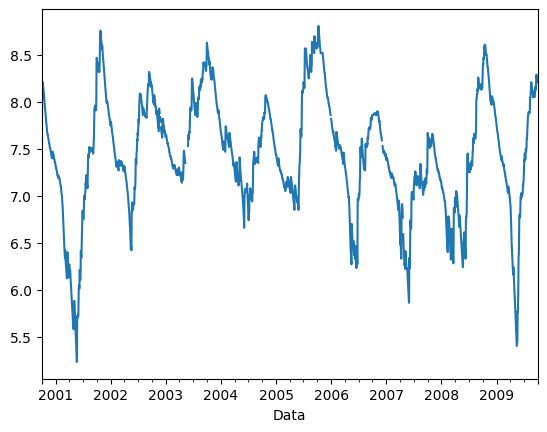

In [29]:
nivel_agua.set_index('Data').AltMediaMedidor.plot.line()

In [30]:
alt.Chart(nivel_agua).mark_line().encode(
    x='Data',
    y='AltMediaMedidor'
)

alt.Chart(...)

In [31]:
alt.Chart(nivel_agua).mark_line().encode(
    x='Data',
    y=alt.Y('AltMediaMedidor:Q', scale=alt.Scale(domain=[5, 9]))
)

alt.Chart(...)

**Análise**: o gráfico mostra fortes ciclos, movimentos regulares de sobe e desce no nível da água. Os **ciclos** mostram os efeitos de chuvas (mais ou menos de junho a novembro) e da estação seca (mais ou menos de dezembro a maio) na Flórida. Os níveis de água são mais altos no final do outono. Olhando mais atentamente, nota-se uma **variação ano a ano**. A estação de seca em 2003 terminou mais cedo, com a primeira tempestade tropical de abril. Em consequência, o nível da água na estação seca em 2003 **não baixou tanto** quanto nos outros anos. A seca na porção sudeste do pais em 2008 e 2009 mostra a **queda brusca** na altura do medidor em 2009, enquanto os picos mais baixos em 2006 e 2007 refletem baixos niveis da água durante a estação das chuvas nesses anos.

### Facetamento

O recurso de facetamento é recorrente em visualização e tem a finalidade de produzir múltiplos gráficos com os mesmos eixos representando variáveis distintas presentes no dado, resultando em uma visualização facetada dos dados.

In [32]:
nivel_agua["Year"] = nivel_agua.Data.dt.year

In [33]:
nivel_agua.head()

,Data,AltMediaMedidor,Year
0,2000-10-01,7.59,2000
1,2000-10-02,7.60,2000
2,2000-10-03,7.82,2000
3,2000-10-04,8.17,2000
4,2000-10-05,8.16,2000


In [34]:
nivel_agua['MonthDay'] = nivel_agua.Data.dt.strftime('%m-%d')

In [35]:
alt.Chart(nivel_agua).mark_line().encode(
    x='MonthDay:T',
    y=alt.Y('AltMediaMedidor:Q', scale=alt.Scale(domain=[5, 9])),
    color='Year:N',
    row=alt.Row("Year:N")
).properties(height=50, width=400)

alt.Chart(...)

In [36]:
nivel_agua.AltMediaMedidor.min()

5.23

In [37]:
alt.Chart(nivel_agua).mark_line().encode(
    x='MonthDay:T',
    y=alt.Y('AltMediaMedidor:Q', scale=alt.Scale(domain=[5, 9]), axis=alt.Axis(titleAngle=0, titlePadding=50)),
    color='Year:N',
    #row=alt.Row("Year:N")
    facet = alt.Facet('Year:N', columns=1)
).properties(height=50, width=400)

alt.Chart(...)

### Sobreposição

A sobreposição de gráficos é usada tanto para comparar diferentes conjuntos de dados visualmente quanto para sobrepor camadas de representação gráfica dos dados (muito usada em gráficos de regressão, por exemplo).

In [38]:
alt.Chart(nivel_agua).mark_line().encode(
    x='MonthDay:T',
    y='AltMediaMedidor:Q',
    color='Year:N'
).properties(height=800, width=1000)

alt.Chart(...)

## RID #2

### Evolução X

Elabore o gráfico de série temporal da evolução de menções ao tema no X.

In [39]:
evolucao_x = pd.read_csv(f'Base RID - Evolução X.csv')

In [40]:
evolucao_x

,Data,Count,Categoria,Análise,Relatório
0,2024-06-27 00:00:00,293,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
1,2024-06-27 01:00:00,133,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
2,2024-06-27 02:00:00,119,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
3,2024-06-27 03:00:00,126,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
4,2024-06-27 04:00:00,79,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
...,...,...,...,...,...
608,2024-07-22 08:00:00,10379,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
609,2024-07-22 09:00:00,10539,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
610,2024-07-22 10:00:00,11199,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio
611,2024-07-22 11:00:00,10373,Eleições EUA,Evolução de menções no X,#2_POLICYREPORT_FGV Comunicação Rio


In [41]:
evolucao_x.dtypes

,0
Data,object
Count,int64
Categoria,object
Análise,object
Relatório,object


Pode ser útil usar a função **resample** - Método prático para conversão de frequência e reamostragem de séries temporais. O objeto deve ter um índice do tipo datetime ( DatetimeIndex , PeriodIndex ou TimedeltaIndex ), ou o chamador deve passar o rótulo de uma série/índice do tipo datetime para o parâmetro de palavra-chave *on*.

In [42]:
evolução_x_dia = evolucao_x.set_index(pd.to_datetime(evolucao_x['Data'])).resample('d').Count.sum() # escolhi usar a soma, pra que cada dia seja a soma de menções das horas daquele dia. mas poderia usar outras agregações também, como média, por exemplo.

In [43]:
evolução_x_dia

,Count
Data,
2024-06-27,42025
2024-06-28,124838
2024-06-29,33618
2024-06-30,32983
2024-07-01,37651
2024-07-02,27545
2024-07-03,37879
2024-07-04,28884
2024-07-05,29718


In [66]:
alt.Chart(evolução_x_dia.reset_index()).mark_line().encode(
    x='Data',
    y=alt.Y('Count:Q')
).properties(height=500, width=700)

alt.Chart(...)

### Associações Lula e Bolsonaro

Gere o gráfico de menções ao tema e a Lula e Bolsonaro no Facebook, utilizando a técnica de facetamento ou sobreposição.

In [46]:
lula_bolsonaro = pd.read_csv(f'RID - Evolução Facebook.csv')

In [47]:
lula_bolsonaro

,Data,Count,Categoria,Análise,Relatório
0,2024-06-27,21,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
1,2024-06-28,70,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
2,2024-06-29,48,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
3,2024-06-30,31,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
4,2024-07-01,76,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
5,2024-07-02,81,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
6,2024-07-03,36,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
7,2024-07-04,56,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
8,2024-07-05,71,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio
9,2024-07-06,45,Associações com Jair Bolsonaro,Associações com Lula e Bolsonaro no Facebook,#2_POLICYREPORT_FGV Comunicação Rio


In [48]:
alt.Chart(lula_bolsonaro).mark_line().encode(
    x='Data:T',
    y='Count:Q',
    color='Categoria:N'
).properties(height=800, width=1000)

alt.Chart(...)

In [49]:
alt.Chart(lula_bolsonaro).mark_line().encode(
    x='Data:T',
    y=alt.Y('Count:Q'),
    color='Categoria:N',
    row=alt.Row("Categoria:N")
).properties(height=300, width=1000)

alt.Chart(...)